# Notebook 3 — Quantifying uncertainty

*Day 5 · put honest error bars on your predictions, then ask whether they're trustworthy.*

In [1]:
# ======================================================================================
# Setup — run this first (you don't need to read it closely).
# It imports a few libraries, sets a shared plot style, and defines the helper functions used
# throughout the notebook (load_data, the plot helpers, the metric helpers, ...).  These are the
# SAME helpers in every notebook, so your results line up with your teammates'.  If a later cell
# says a helper is "not defined", you probably skipped this cell — run it, then carry on.
# ======================================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------------------
# Paths — resolved so the notebooks work whether they're run from the materials folder or
# from solutions/ .  Outputs and figures always land in the materials root.
# ----------------------------------------------------------------------------------------
def _materials_root():
    """Folder that contains data/ ; searched upward from the working directory."""
    here = os.path.abspath(os.getcwd())
    for d in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        if os.path.isdir(os.path.join(d, "data")):
            return d
    return here

ROOT = _materials_root()
DATA_DIR = os.path.join(ROOT, "data")
OUTPUTS_DIR = os.path.join(ROOT, "outputs")
FIGURES_DIR = os.path.join(ROOT, "figures")
for _d in (DATA_DIR, OUTPUTS_DIR, FIGURES_DIR):
    os.makedirs(_d, exist_ok=True)

# Module-level cache of the reconstruction basis (set by load_data; used by reconstruct_spectrum).
_RECON = {"wavelength": None, "basis": None, "is_mock": True}
_RAW_CACHE = {}   # path -> full arrays, so repeated load_data() calls don't re-read the file

# Default working-set size.  The real catalog is ~200k stars; we train on a fast deterministic
# subsample by default so in-class fits stay quick AND every notebook sees the SAME stars (which
# keeps the NB2->NB3->NB4 saved-prediction hand-off aligned).  Pass n=None to use the WHOLE
# high-quality catalog (the "does more data help?" / label-transfer-at-scale exercise).
DEFAULT_N = 30000

# Canonical label columns.  The modelling track predicts [Fe/H]; Teff & logg are explored and
# used as the axes for residual / coverage maps.  alpha/age/dist are extra "explore" labels.
LABEL_COLS = ["Teff", "logg", "FeH", "alpha", "age", "dist"]
PRETTY = {"Teff": r"$T_\mathrm{eff}$ [K]", "logg": r"$\log g$ [dex]",
          "FeH": r"[Fe/H] [dex]", "alpha": r"[$\alpha$/M] [dex]",
          "age": "age [Gyr]", "dist": "distance [pc]"}


# ========================================================================================
# Plot style
# ========================================================================================
def set_plot_style():
    """Consistent, readable matplotlib defaults.  Called once in setup."""
    plt.rcParams.update({
        "figure.figsize": (6.4, 4.4), "figure.dpi": 110, "savefig.dpi": 150,
        "savefig.bbox": "tight", "font.size": 12, "axes.titlesize": 13,
        "axes.labelsize": 12, "axes.grid": True, "grid.alpha": 0.25,
        "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
        "legend.frameon": False, "legend.fontsize": 11, "lines.linewidth": 2.0,
        "scatter.edgecolors": "none", "image.cmap": "viridis",
    })

# A small colour-blind-friendly palette used across the materials for named series.
COLORS = {"linear": "#888888", "knn": "#0072B2", "rf": "#009E73",
          "nn": "#D55E00", "native": "#0072B2", "conformal": "#D55E00",
          "truth": "#222222", "accent": "#CC79A7"}


# ========================================================================================
# Data loading  (the mock generator lives here so the shipped npz and the on-the-fly
# fallback are guaranteed identical)
# ========================================================================================
_C2_NM = 1.438777e7  # second radiation constant hc/k in nm*K


def _build_basis(wave_min=336.0, wave_max=1020.0, n_wave=343, n_bp=55, n_rp=55):
    """Smooth windowed-cosine modes per band, orthonormalised.  Low modes are broad
    (continuum), high modes wiggly (fine structure).  reconstruct = B @ coeff."""
    wave = np.linspace(wave_min, wave_max, n_wave)
    cols = []
    def band(lo, hi, n_modes):
        x = (wave - lo) / (hi - lo)
        win = np.where((x >= 0) & (x <= 1), np.sin(np.clip(x, 0, 1) * np.pi) ** 0.5, 0.0)
        for j in range(n_modes):
            cols.append(np.cos(j * np.pi * np.clip(x, 0, 1)) * win)
    band(wave_min, 690.0, n_bp)
    band(630.0, wave_max, n_rp)
    Q, _ = np.linalg.qr(np.column_stack(cols))
    return wave, Q[:, :n_bp + n_rp]


def _synthesize_mock(n=50000, seed=42):
    """
    # MOCK DATA — swap for the real Zenodo loader.
    Physically-motivated synthetic stand-in for the Laroche & Speagle APOGEE x Gaia-XP
    cross-match.  Returns the same dict that the shipped npz stores.  See the build spec
    and _build/make_mock_dataset.py for the full rationale.  In one sentence: a Planck
    continuum sets Teff; Balmer lines reinforce Teff; gravity-sensitive molecular bands
    carry log g; SHALLOW metal lines (suppressed at high Teff) carry the hard, heteroscedastic
    [Fe/H]; reddening + hidden factors add a realistic irreducible (aleatoric) floor.
    """
    rng = np.random.default_rng(seed)
    wave, B = _build_basis()
    W = wave.size

    # --- labels with Kiel-diagram structure: dwarfs + giants + red clump + metal-poor halo ---
    is_giant = rng.random(n) < 0.45
    Teff = np.empty(n); logg = np.empty(n); FeH = np.empty(n)
    nd, ng = np.count_nonzero(~is_giant), np.count_nonzero(is_giant)
    Td = 4000 + 3100 * rng.beta(1.5, 2.5, nd)
    Teff[~is_giant] = Td
    logg[~is_giant] = 4.62 - 0.00013 * (Td - 4500) + rng.normal(0, 0.10, nd)
    FeH[~is_giant] = rng.normal(-0.05, 0.25, nd)
    Tg = 3800 + 1700 * rng.beta(2.0, 2.3, ng)
    Teff[is_giant] = Tg
    logg[is_giant] = 1.7 + 0.00095 * (Tg - 3800) + rng.normal(0, 0.33, ng)
    FeH[is_giant] = rng.normal(-0.28, 0.34, ng)
    clump = is_giant & (rng.random(n) < 0.33); nc = np.count_nonzero(clump)
    Teff[clump] = rng.normal(4800, 140, nc); logg[clump] = rng.normal(2.45, 0.11, nc)
    FeH[clump] = rng.normal(-0.10, 0.20, nc)
    halo = rng.random(n) < 0.06; nh = np.count_nonzero(halo)
    Teff[halo] = rng.normal(4900, 450, nh)
    logg[halo] = np.clip(rng.normal(2.2, 0.7, nh), 0.5, 3.6)
    FeH[halo] = rng.normal(-1.45, 0.45, nh)
    is_giant = is_giant | halo
    Teff = np.clip(Teff, 3500, 7600); logg = np.clip(logg, 0.3, 5.0); FeH = np.clip(FeH, -2.4, 0.55)
    alpha = np.clip(0.13 - 0.24 * FeH + rng.normal(0, 0.035, n), -0.05, 0.5)
    age = np.clip(2.0 + 6.5 * is_giant - 3.5 * FeH + rng.normal(0, 1.8, n), 0.3, 13.5)
    dist = np.exp(rng.normal(6.7, 0.9, n)) * (1.0 + 1.5 * is_giant)

    # --- forward model: labels -> flux ---
    def gauss(c, w): return np.exp(-0.5 * ((wave - c) / w) ** 2)
    x = _C2_NM / (wave[None, :] * Teff[:, None])
    flux = wave[None, :] ** -5 / np.expm1(np.clip(x, 1e-6, 700))
    flux = flux / flux.mean(axis=1, keepdims=True)
    jump = 1.0 / (1.0 + np.exp((wave - 382.0) / 6.0))
    flux *= 1.0 - (0.18 * np.clip((Teff - 5200) / 2500, 0, 1.4) * (1 + 0.15 * (4.5 - logg)))[:, None] * jump[None, :]
    balmer = sum(a * gauss(c, 9.0) for c, a in [(434., .9), (486.1, 1.1), (656.3, 1.)])
    bstr = np.clip(np.exp((Teff - 5200) / 1500), 0.15, 6.0) * (1 + 0.12 * (4.5 - logg))
    flux *= 1.0 - 0.012 * bstr[:, None] * balmer[None, :]
    g_dwarf = np.clip(logg - 3.0, 0, 2.0)[:, None]; g_giant = np.clip(3.6 - logg, 0, 3.2)[:, None]
    coolf = np.clip((5500 - Teff) / 2000.0, 0.2, 1.4)[:, None]
    grav = np.zeros((n, W))
    for c, a in [(488., 1.), (521., .9), (692., .8)]: grav += a * g_dwarf * gauss(c, 15.)[None, :]
    for c, a in [(421., .9), (793., .8), (883., 1.)]: grav += a * g_giant * gauss(c, 17.)[None, :]
    flux *= 1.0 - 0.038 * coolf * grav
    metal = sum(a * gauss(c, 11.0) for c, a in
                [(422.7, 1.), (460., .7), (517.3, 1.2), (527., .9), (589.3, 1.1),
                 (670.8, .6), (770., .6), (850., .8), (920., .5)])
    # Line depth scales with metal abundance (metal-poor stars have WEAK lines -> little [Fe/H]
    # information -> the dominant, physically-correct source of heteroscedastic [Fe/H] error).
    # Temperature only mildly suppresses lines; gravity gives luminous giants slightly weaker,
    # more variable lines (they are also the sparsest, most-extrapolated regime).
    mstr = 10.0 ** (0.55 * FeH)
    tsupp = np.clip(np.exp(-(Teff - 4500) / 4800.0), 0.6, 1.25)
    line_amp = (mstr * tsupp * np.clip(0.7 + 0.22 * logg, 0.7, 1.4))[:, None]
    flux *= 1.0 - 0.045 * line_amp * metal[None, :]
    ebv = np.abs(rng.normal(0, 0.11, n))[:, None]
    ext = (550.0 / wave) ** 1.0
    flux *= 10.0 ** (-0.4 * 1.6 * ebv * (ext / ext.mean())[None, :])
    P = np.column_stack([np.sin(f * np.pi * (wave - wave[0]) / (wave[-1] - wave[0])) for f in (1.5, 3.5, 6.5)])
    flux *= 1.0 + 0.004 * (rng.normal(0, 1, (n, 3)) @ P.T)
    gflux = np.exp(rng.normal(0.0, 0.8, n))
    snr = np.clip(58 * gflux ** 0.30 * np.exp(rng.normal(0, 0.30, n)), 20, 400)
    obs = gflux[:, None] * np.clip(flux, 1e-3, None)
    obs = obs + rng.normal(0, 1, obs.shape) * (obs.mean(axis=1, keepdims=True) / snr[:, None])
    X = (obs @ B).astype(np.float32)
    return dict(X=X, Teff=Teff, logg=logg, FeH=FeH, alpha=alpha, age=age, dist=dist,
                snr=snr, gflux=gflux, source_id=(1_000_000_000 + np.arange(n)),
                wavelength=wave, basis=B.astype(np.float32), is_mock=True)


def load_data(path=None, n=DEFAULT_N, seed=0, verbose=True):
    """
    Load the dataset in one line:  X, y, meta = load_data()

    Parameters
    ----------
    n    : working-set size.  Returns a deterministic random subsample of `n` stars (default
           DEFAULT_N=30000) so fits are fast and every notebook sees the same stars.  Pass
           `n=None` to use the ENTIRE high-quality catalog (the scale-up exercise) — slower.
    seed : seed for the subsample (keep it fixed so the NB2->NB3->NB4 hand-off stays aligned).

    Returns
    -------
    X    : float array, shape (n, 110) — the Gaia XP coefficients (55 BP + 55 RP).
    y    : DataFrame with columns Teff, logg, FeH (+ alpha, dist) — the labels.
    meta : DataFrame with source_id, snr, gflux — per-star bookkeeping (gflux is the
           brightness scale used by normalize_by_g).
    """
    if path is None:
        for cand in ("xp_apogee_real.npz", "xp_apogee_mock.npz"):
            p = os.path.join(DATA_DIR, cand)
            if os.path.exists(p):
                path = p
                break
    key = path if path is not None else "__synth__"
    if key in _RAW_CACHE:
        data = _RAW_CACHE[key]
    elif path is not None and os.path.exists(path):
        d = np.load(path, allow_pickle=True)
        data = {k: d[k] for k in d.files}
        _RAW_CACHE[key] = data
    else:
        if verbose:
            print("No data file found — synthesising the mock dataset on the fly.")
        data = _synthesize_mock()
        _RAW_CACHE[key] = data
    is_mock = bool(data.get("is_mock", True))
    src = os.path.basename(path) if path else "synthesised mock"

    _RECON["wavelength"] = np.asarray(data["wavelength"], float)
    _RECON["basis"] = np.asarray(data["basis"], float)
    _RECON["is_mock"] = is_mock

    X_all = np.asarray(data["X"], dtype=float)
    N = X_all.shape[0]
    if n is not None and n < N:
        sel = np.sort(np.random.default_rng(seed).permutation(N)[:n])
    else:
        sel = np.arange(N)
    X = X_all[sel]
    y = pd.DataFrame({c: np.asarray(data[c], float)[sel] for c in LABEL_COLS if c in data})
    meta = pd.DataFrame({k: np.asarray(data[k]).ravel()[sel] for k in ("source_id", "snr", "gflux") if k in data})
    if verbose:
        tag = "MOCK (synthetic)" if is_mock else "REAL (Gaia XP x APOGEE)"
        extra = f" (subsampled from {N:,}; pass n=None for all)" if len(sel) < N else ""
        print(f"Loaded {src}: {tag}  —  {X.shape[0]:,} stars{extra}, {X.shape[1]} coefficients.")
    return X, y, meta


# ========================================================================================
# Spectrum reconstruction
# ========================================================================================
def reconstruct_spectrum(coeffs):
    """
    Turn a star's 110 XP coefficients into a sampled spectrum: returns (wavelength_nm, flux).
    Accepts a single (110,) vector or an (M, 110) batch.

    On the shipped data this uses the stored smooth basis (B @ coeff) — no extra packages.

    # REAL DATA: with the genuine Gaia archive continuous representation you would instead
    # reconstruct with GaiaXPy, e.g.:
    #     from gaiaxpy import calibrate
    #     sampling = np.arange(336, 1021, 2.0)              # nm
    #     spectra, sampled_wl = calibrate(source_dataframe, sampling=sampling, save_file=False)
    # The stored basis is recovered from Zenodo's wavelength-space spectra at curation time
    # (see _build/prepare_real_data.py), so this helper stays identical for mock and real.
    """
    if _RECON["basis"] is None:
        load_data(verbose=False)
    B, wave = _RECON["basis"], _RECON["wavelength"]
    coeffs = np.asarray(coeffs, float)
    flux = coeffs @ B.T
    return wave, flux


# ========================================================================================
# Preprocessing recipe:  normalize by the G-band  ->  standardize (fit on train only)
# ========================================================================================
def normalize_by_g(X, g):
    """Divide each star's coefficients by its G-band brightness scale `g` (a column of meta).
    Removes brightness/distance and keeps the spectral SHAPE — what carries the labels."""
    g = np.asarray(g, float).reshape(-1, 1)
    return np.asarray(X, float) / g


def standardize(X_train, X_other):
    """Z-score the coefficients using statistics from the TRAINING set only, then apply the
    same shift/scale to another split.  Returns (X_train_scaled, X_other_scaled).
    (Equivalent to sklearn's StandardScaler fit on train; spelled out for clarity.)"""
    mu = X_train.mean(axis=0, keepdims=True)
    sd = X_train.std(axis=0, keepdims=True)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return (X_train - mu) / sd, (X_other - mu) / sd


# ========================================================================================
# Splitting  (fixed seed so every student gets the same train / cal / test stars)
# ========================================================================================
def train_cal_test_split(X, y, seed=0, fracs=(0.6, 0.2, 0.2)):
    """Reproducible 60/20/20 split into train / calibration / test.
    Returns a dict with X_* arrays, y_* DataFrames, and idx_* index arrays.
    Calibration is held out for the uncertainty work in NB3/NB4."""
    X = np.asarray(X, float)
    y = y.reset_index(drop=True)
    n = X.shape[0]
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    n_tr = int(fracs[0] * n); n_ca = int(fracs[1] * n)
    i_tr, i_ca, i_te = idx[:n_tr], idx[n_tr:n_tr + n_ca], idx[n_tr + n_ca:]
    return {
        "X_train": X[i_tr], "X_cal": X[i_ca], "X_test": X[i_te],
        "y_train": y.iloc[i_tr].reset_index(drop=True),
        "y_cal": y.iloc[i_ca].reset_index(drop=True),
        "y_test": y.iloc[i_te].reset_index(drop=True),
        "idx_train": i_tr, "idx_cal": i_ca, "idx_test": i_te,
    }


# ========================================================================================
# Models — the four estimators the students compare.  Defined ONCE here so NB2, NB3 and NB4
# build byte-identical models, which is what lets predictions and intervals line up across
# notebooks and across the three students.  Each is a Pipeline(StandardScaler + estimator),
# so you feed it the G-normalized coefficients and it standardizes internally (fit on train).
# ========================================================================================
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

MODEL_NAMES = {"linear": "Linear regression (baseline)", "knn": "K-nearest neighbors",
               "rf": "Random forest", "nn": "Neural network (MLP)"}

def make_model(name, **overrides):
    """Canonical Pipeline(StandardScaler + estimator) for a model name in {linear,knn,rf,nn}.
    Pass overrides to tune one knob, e.g. make_model('knn', n_neighbors=20).  The step name for
    the estimator is its lowercased class name (e.g. 'kneighborsregressor') — handy in NB3 when
    you reach inside the fitted pipeline for a model-native uncertainty."""
    if name == "linear":
        est = LinearRegression(**overrides)
    elif name == "knn":
        est = KNeighborsRegressor(**{"n_neighbors": 12, **overrides})
    elif name == "rf":
        est = RandomForestRegressor(**{"n_estimators": 150, "min_samples_leaf": 3,
                                       "random_state": 0, "n_jobs": -1, **overrides})
    elif name == "nn":
        est = MLPRegressor(**{"hidden_layer_sizes": (64, 64), "alpha": 1e-3, "max_iter": 500,
                              "early_stopping": True, "random_state": 0, **overrides})
    else:
        raise ValueError(f"unknown model '{name}' (use one of {list(MODEL_NAMES)})")
    return make_pipeline(StandardScaler(), est)


# ========================================================================================
# Metrics
# ========================================================================================
def regression_metrics(y_true, y_pred):
    """Return a dict of RMSE, MAE, bias (mean signed error), and R^2."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    err = y_pred - y_true
    ss_res = float(np.sum(err ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2)) or 1.0
    return {"RMSE": float(np.sqrt(np.mean(err ** 2))), "MAE": float(np.mean(np.abs(err))),
            "bias": float(np.mean(err)), "R2": float(1.0 - ss_res / ss_tot)}


# ========================================================================================
# Plots — predictions & residuals
# ========================================================================================
def plot_pred_vs_true(y_true, y_pred, title=None, ax=None, color=None, label=None, units=""):
    """Scatter of predicted vs true with the 1:1 line and an RMSE annotation."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    if ax is None:
        _, ax = plt.subplots()
    lo = min(y_true.min(), y_pred.min()); hi = max(y_true.max(), y_pred.max())
    pad = 0.04 * (hi - lo + 1e-9)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "--", color="0.4", lw=1.3, zorder=1)
    ax.scatter(y_true, y_pred, s=8, alpha=0.35, color=color or COLORS["rf"], label=label, zorder=2)
    m = regression_metrics(y_true, y_pred)
    ax.text(0.04, 0.96, f"RMSE = {m['RMSE']:.3g}{units}\nbias = {m['bias']:+.2g}{units}",
            transform=ax.transAxes, va="top", ha="left", fontsize=10,
            bbox=dict(boxstyle="round", fc="white", ec="0.8", alpha=0.85))
    ax.set_xlabel(f"true{(' ' + units) if units else ''}")
    ax.set_ylabel(f"predicted{(' ' + units) if units else ''}")
    ax.set_xlim(lo - pad, hi + pad); ax.set_ylim(lo - pad, hi + pad)
    ax.set_aspect("equal", "box")
    if title:
        ax.set_title(title)
    if label:
        ax.legend(loc="lower right")
    return ax


def plot_residuals(y_true, y_pred, feature=None, feature_name="value", ax=None, color=None):
    """Residuals (pred - true) vs the truth, or vs an external `feature` (e.g. Teff).
    A flat band around zero means well-behaved errors; trends/fans flag structure."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    resid = y_pred - y_true
    xx = np.asarray(feature, float) if feature is not None else y_true
    xlabel = feature_name if feature is not None else "true value"
    if ax is None:
        _, ax = plt.subplots()
    ax.axhline(0.0, color="0.4", ls="--", lw=1.3, zorder=1)
    ax.scatter(xx, resid, s=8, alpha=0.35, color=color or COLORS["rf"], zorder=2)
    ax.set_xlabel(xlabel); ax.set_ylabel("residual (pred − true)")
    return ax


# ========================================================================================
# Uncertainty — coverage, reliability, comparison
# ========================================================================================
def empirical_coverage(y_true, lower, upper):
    """Fraction of true values that fall inside [lower, upper]."""
    y_true = np.asarray(y_true, float)
    return float(np.mean((y_true >= np.asarray(lower, float)) & (y_true <= np.asarray(upper, float))))


def plot_reliability(y_true, lower, upper, target=None, feature=None, feature_name="bin",
                     n_bins=8, ax=None, color=None, label=None):
    """
    'Are the error bars honest, everywhere?'  Bins the points (by an external `feature` such
    as Teff if given, else by the interval centre) and plots empirical coverage per bin against
    the `target` line.  Bars sitting below the target reveal where intervals under-cover.
    """
    y_true = np.asarray(y_true, float)
    lower = np.asarray(lower, float); upper = np.asarray(upper, float)
    inside = (y_true >= lower) & (y_true <= upper)
    xx = np.asarray(feature, float) if feature is not None else 0.5 * (lower + upper)
    if ax is None:
        _, ax = plt.subplots()
    edges = np.quantile(xx, np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1e-9
    centers, cov = [], []
    for i in range(n_bins):
        m = (xx >= edges[i]) & (xx < edges[i + 1])
        if m.sum() >= 5:
            centers.append(xx[m].mean()); cov.append(inside[m].mean())
    ax.plot(centers, cov, "o-", color=color or COLORS["native"], label=label)
    if target is not None:
        ax.axhline(target, color="0.4", ls="--", lw=1.3, label=f"target = {target:.0%}")
    ax.set_xlabel(feature_name if feature is not None else "interval centre")
    ax.set_ylabel("empirical coverage")
    ax.set_ylim(0, 1.02)
    if target is not None or label:
        ax.legend(loc="lower center")
    return ax


def compare_intervals(y_true, intervals, target=None, ax=None):
    """
    Compare several named interval sets.  `intervals` maps name -> (lower, upper).
    Draws two bars per method — coverage and median width — and returns a tidy summary table.
    """
    y_true = np.asarray(y_true, float)
    rows = []
    for name, (lo, hi) in intervals.items():
        rows.append({"method": name, "coverage": empirical_coverage(y_true, lo, hi),
                     "median_width": float(np.median(np.asarray(hi, float) - np.asarray(lo, float)))})
    tbl = pd.DataFrame(rows).set_index("method")
    if ax is None:
        _, ax = plt.subplots(1, 2, figsize=(9.5, 4.0))
    names = list(tbl.index)
    cols = [COLORS.get(n.split()[0].lower(), COLORS["accent"]) for n in names]
    ax[0].bar(names, tbl["coverage"], color=cols)
    if target is not None:
        ax[0].axhline(target, color="0.4", ls="--", lw=1.3, label=f"target = {target:.0%}")
        ax[0].legend()
    ax[0].set_ylabel("empirical coverage"); ax[0].set_ylim(0, 1.02); ax[0].set_title("Coverage")
    ax[1].bar(names, tbl["median_width"], color=cols)
    ax[1].set_ylabel("median interval width"); ax[1].set_title("Sharpness (narrower is better)")
    for a in ax:
        a.tick_params(axis="x", rotation=20)
    return tbl


# ========================================================================================
# Small convenience used in worked examples
# ========================================================================================
def savefig(name, fig=None):
    """Save a figure into figures/ for reuse on the poster.  Returns the path."""
    path = os.path.join(FIGURES_DIR, name)
    (fig or plt.gcf()).savefig(path)
    return path


def save_outputs(filename, **arrays):
    """Save named arrays into outputs/<filename> (the shared NB2->NB3->NB4 contract)."""
    path = os.path.join(OUTPUTS_DIR, filename)
    np.savez(path, **arrays)
    return path


def load_outputs(filename):
    """Load an outputs/ npz written by an earlier notebook; returns a dict of arrays."""
    d = np.load(os.path.join(OUTPUTS_DIR, filename), allow_pickle=True)
    return {k: d[k] for k in d.files}

set_plot_style()
print('Setup complete — helpers ready.')


Setup complete — helpers ready.


## Welcome — from predictions to honest error bars

In Notebook 2 you trained a model that takes a star's 110 Gaia XP numbers and predicts its
metallicity **[Fe/H]**, and you saw the errors weren't uniform — they piled up on **metal-poor
stars and luminous giants**. Today we put **honest error bars** on those predictions.

A single predicted number hides how *sure* we are. Today's job: turn each prediction into an
**interval** — a range like "[Fe/H] is between −0.55 and −0.25" — that we can actually *trust*.

Here is the day's arc:

1. **One shared interval** everybody builds the same way (a constant ± band).
2. **One interval matched to your model** (read out of KNN's neighbours / RF's trees / NN's ensemble).
3. **Check if either is calibrated** — and find exactly where it isn't.

The rhythm is the same as always: **Explain → Worked (run it) → Your turn (edit it) → Explore (play).**

> Runs top-to-bottom as shipped. If a cell errors, grab a TA.

The honesty gap you'll find at the end is exactly what **Notebook 4** (conformal prediction) sets
out to fix — and where it still strains.

## 0 · Pick your model and load Notebook 2's predictions

One variable personalises this whole notebook. Set **`MODEL`** to your assigned model:

| Student | `MODEL` |
|---|---|
| A | `"knn"` (K-nearest neighbours) |
| B | `"rf"` (random forest) |
| C | `"nn"` (neural network) |

The shared **linear baseline** (`"linear"`) is loaded alongside for context.

Notebook 2 saved each model's predictions to `outputs/{model}_preds.npz` with four arrays:
`y_cal_true`, `y_cal_pred`, `y_test_true`, `y_test_pred`. We **reuse** them so we don't have to
refit anything yet.

One term to define now — the **calibration set**: the held-out chunk of stars that is *neither*
training *nor* test. We set it aside in Notebook 2 precisely to **check and size uncertainties**.
This is the first notebook where it earns its keep.

In [2]:
import warnings
from scipy.stats import norm

MODEL = "knn"   # <- your turn: set to YOUR assigned model: "knn" (A), "rf" (B), or "nn" (C)
TARGET_LEVEL = 0.90                      # we want honest 90% intervals all day
k = norm.ppf((1 + TARGET_LEVEL) / 2)     # Gaussian multiplier: ~1.645 for 90% (a z-score)
print(f"MODEL = {MODEL!r}   nominal level = {TARGET_LEVEL:.0%}   k = {k:.3f}")

# Notebook 2 wrote these. load_outputs returns a dict of arrays.
# (If this raises FileNotFoundError, run Notebook 2 first — it writes outputs/{model}_preds.npz.)
try:
    preds = load_outputs(f"{MODEL}_preds.npz")     # your model
    base  = load_outputs("linear_preds.npz")        # the shared baseline, for context
except FileNotFoundError:
    raise FileNotFoundError("Missing outputs/*_preds.npz — run Notebook 2 first, then re-run this cell.")

print("keys:", list(preds.keys()))
print(f"calibration stars: {preds['y_cal_true'].size:,}   test stars: {preds['y_test_true'].size:,}")

MODEL = 'knn'   nominal level = 90%   k = 1.645
keys: ['y_cal_true', 'y_cal_pred', 'y_test_true', 'y_test_pred']
calibration stars: 6,000   test stars: 6,000


## 1 · Why a single number isn't enough

A point prediction hides how confident the model is. "[Fe/H] = −0.30" could mean ±0.03 or ±0.30 —
those are *completely different scientific claims*. One says we've pinned the composition; the other
says we've barely constrained it. Science needs the **range**, not just the centre.

Some vocabulary we'll use all day:

- **Point estimate** — the single best-guess number (what Notebook 2 produced).
- **Prediction interval** — a range `[lower, upper]` meant to *contain* the true value.
- **Uncertainty** — the half-width of that interval, the "± part."

The goal for today, in one sentence: **every prediction should come with an interval we can trust.**

*(For the formal version of "a 90% interval should contain the truth 90% of the time," see
Angelopoulos & Bates 2021, [arXiv:2107.07511](https://arxiv.org/abs/2107.07511), §1–2.)*

## 1.1 · Two flavours of uncertainty: aleatoric vs epistemic

Uncertainty comes in two kinds, and telling them apart is one of the big ideas of this project.

**Aleatoric** uncertainty is *irreducible noise in the data itself* (from Latin *alea*, dice).
Two sources matter here. First, **photon noise**: a telescope counts a random, finite number of
photons, so every measured spectrum jitters a little. Second — and more importantly here —
**information that simply isn't there**. The features that reveal [Fe/H] are **weak metal absorption
lines** (small dips where metal atoms absorb light). In **metal-poor stars** those lines are
genuinely faint, so two stars with rather different [Fe/H] can produce nearly identical Gaia
spectra. *No model can undo this — more of the same data won't help.*

This is why, **in our data, the [Fe/H] error is larger for metal-poor stars** (and, as you'll see,
for luminous giants). When the noise size changes across the data like this, we call it
**heteroscedastic** ("different scatter"); the opposite — constant noise — is **homoscedastic**.
We'll *measure* this later today.

The real-science version: Laroche & Speagle (2025,
[arXiv:2404.07316](https://arxiv.org/abs/2404.07316)) found Gaia's chemical information is rich for
metal-rich disk stars and fades for the metal-poor, sparsely-sampled halo — the same failure we'll
find here is the one real astronomers wrestle with.

**Epistemic** uncertainty is *the model's own ignorance* (from Greek *epistēmē*, knowledge) — from
having seen too few similar examples. It is large in **sparsely-sampled regions** (few nearby
training stars) and small where the training data is dense. Our **luminous giants** (low surface
gravity, `log g`) sit in exactly such a sparse, most-extrapolated corner. *This flavour shrinks as
you collect more data*, especially from the under-sampled corners.

Why the distinction matters: **the fix differs.** Aleatoric → honestly report a *wider* error bar.
Epistemic → *go get more data* (from the under-sampled corners). Most simple methods hand you *one*
number that blends them; knowing which dominates tells you which lever to pull.

*(For a careful treatment, see Hüllermeier & Waegeman 2021,
[arXiv:1910.09457](https://arxiv.org/abs/1910.09457).)*

## 2 · A shared interval everyone builds (constant residual scatter)

The simplest honest interval: measure the **typical size of our mistakes** on held-out data, then
draw the *same* ± band around every prediction.

- A **residual** is `predicted − true` — the signed error on one star.
- Its **standard deviation σ** is a single number summarising "how far off we usually are."

> **⚠ Use the calibration set, not the training set.** The model already fit the training points,
> so its training residuals are optimistically small — they would give dishonestly *narrow*
> intervals. The **calibration** stars are held out, so σ measured on them is honest.

The multiplier `k` (≈ 1.645 for 90%) comes from assuming errors are roughly **Gaussian**
(bell-shaped): ±1.645σ brackets the middle 90% of a bell curve. That assumption is only
*approximately* true here — and where it breaks is one reason this interval can mis-cover (and a
reason Notebook 4's conformal method, which assumes *no* bell curve, is worth it).

Its built-in weakness, stated up front: **one width for every star** (it's homoscedastic). So it
*cannot* widen for the genuinely harder stars even when their true error is larger. We'll watch that
fail next.

In [3]:
# 1) Residuals on the HELD-OUT calibration set (honest; the model never fit these).
resid_cal = preds["y_cal_pred"] - preds["y_cal_true"]     # signed errors, shape (n_cal,)
sigma = resid_cal.std()                                   # ONE number: typical [Fe/H] error (dex)
print(f"calibration residual scatter   sigma = {sigma:.3f} dex")
print(f"calibration bias (mean error)        = {resid_cal.mean():+.3f} dex   "
      f"(near 0 -> no systematic offset)")

# 2) The SAME +/- k*sigma band on every test star.
y_test_pred = preds["y_test_pred"]
y_test_true = preds["y_test_true"]
shared_lower = y_test_pred - k * sigma
shared_upper = y_test_pred + k * sigma
print(f"every interval has the SAME half-width = {k * sigma:.3f} dex   (one size fits all)")

calibration residual scatter   sigma = 0.188 dex
calibration bias (mean error)        = +0.004 dex   (near 0 -> no systematic offset)
every interval has the SAME half-width = 0.310 dex   (one size fits all)


### Did it land at 90%?

Define **empirical coverage** = the fraction of true values that actually fall inside the interval,
measured on **test** stars the model never saw. Define **nominal (target) coverage** = the level we
*asked* for (here 0.90). An interval is **calibrated** when empirical ≈ nominal.

One subtlety to keep straight: a "90% interval" is a statement about the **long-run fraction across
many stars**, not a 90% chance for any single star.

In [4]:
cov_shared = empirical_coverage(y_test_true, shared_lower, shared_upper)
print(f"shared interval: empirical coverage on test = {cov_shared:.1%}   (target = {TARGET_LEVEL:.0%})")

shared interval: empirical coverage on test = 91.8%   (target = 90%)


### The catch: is it honest *everywhere*?

A single average can hide a lot. Let's **slice** the coverage — bin the test stars and measure
coverage *within each bin* — to see whether the interval is honest for every *kind* of star, or
only on average.

We'll slice along two physical axes the constant interval can't see:

- **surface gravity `log g`** — separates compact **dwarfs** (high `log g`, ≈ 4–5) from bloated,
  luminous **giants** (low `log g`, ≈ 1–3). Giants are the sparse, most-extrapolated stars.
- **metallicity `[Fe/H]`** — **metal-poor** stars (low `[Fe/H]`) have the faintest metal lines, so
  the least chemical information.

This is a **discovery** step: we don't know in advance which bins break. Let the plots tell us.

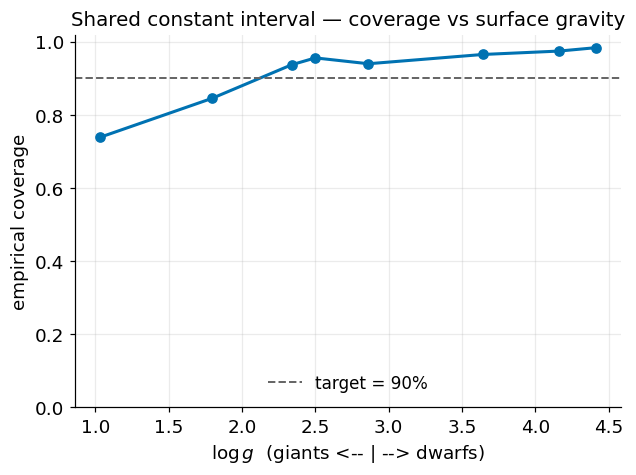

In [5]:
# The saved predictions are in the SAME ORDER as a fresh seed=0 split (NB2 normalized BEFORE
# splitting), so the test labels line up row-for-row. Reload them once (cheap; no model involved).
X, y, meta = load_data(verbose=False)
Xn = normalize_by_g(X, meta["gflux"])               # brightness -> spectral shape (the recipe)
sp = train_cal_test_split(Xn, y, seed=0)            # same split as NB2 -> rows align with saved preds
logg_test = sp["y_test"]["logg"].to_numpy()
feh_test  = sp["y_test"]["FeH"].to_numpy()
assert logg_test.size == y_test_true.size, "split mismatch: did NB2 normalize_by_g BEFORE seed=0 split?"
assert np.allclose(sp["y_test"]["FeH"].to_numpy(), y_test_true), "row order mismatch with saved preds!"

# Coverage sliced by SURFACE GRAVITY (giants on the low-log g end).
ax = plot_reliability(y_test_true, shared_lower, shared_upper,
                      target=TARGET_LEVEL,
                      feature=logg_test, feature_name=r"$\log g$  (giants <-- | --> dwarfs)")
ax.set_title("Shared constant interval — coverage vs surface gravity")
savefig(f"{MODEL}_shared_reliability_vs_logg.png")
plt.show()

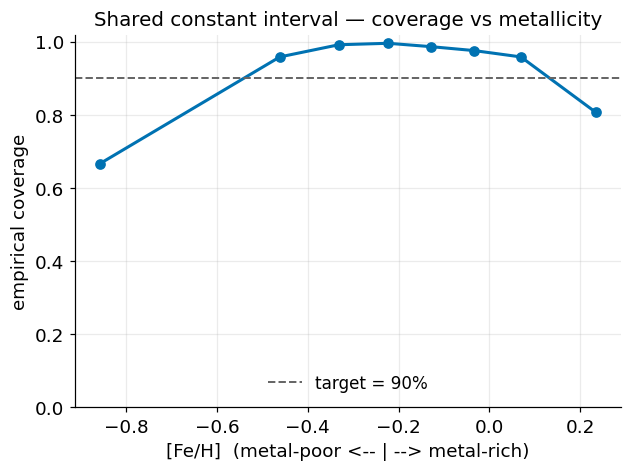

In [6]:
# Same diagnostic, now sliced by METALLICITY (metal-poor on the left).
ax = plot_reliability(y_test_true, shared_lower, shared_upper,
                      target=TARGET_LEVEL,
                      feature=feh_test, feature_name=r"[Fe/H]  (metal-poor <-- | --> metal-rich)")
ax.set_title("Shared constant interval — coverage vs metallicity")
savefig(f"{MODEL}_shared_reliability_vs_FeH.png")
plt.show()

**What we just found.** Marginally the shared interval is ≈ 90% — but conditionally it is
**under-covering the luminous giants and the metal-poor stars**, and **over-covering the
metal-rich dwarfs**. One width can't be right everywhere when the true error isn't constant.

That gap is the whole point of the rest of today (and of Notebook 4). Next: can a model build a
*per-star* width out of its own internals — one that widens where the stars are hard?

## 3 · An interval matched to your model

The shared interval is blunt: one width for everyone. Each model can do better by reading an
uncertainty **out of its own internals** — its **native uncertainty** (a spread the model already
"knows," no extra calibration step).

One recipe per model, so all three students see the menu:

- **KNN (A):** for a test star, look at its *k* nearest training stars and take the **spread of
  their true [Fe/H]**. Neighbours disagree → large uncertainty.
- **RF (B):** a forest is many trees that disagree; the **spread of their individual predictions**
  is a free uncertainty.
- **NN (C):** train a **small ensemble** of the same network with different random seeds; the
  **spread of their predictions** is the uncertainty.

**Why rebuild the model here?** The saved `.npz` only stored the final numbers — the neighbours /
trees / ensemble members live *inside* the fitted model. So we reload the data, redo the **same**
seed=0 split, and refit with `make_model(MODEL)` (the exact pipeline from Notebook 2). It's quick at
this scale.

**Honesty preview:** these native intervals are the model's **raw** uncertainty — *not guaranteed
calibrated*. Finding them imperfect in §4 is the *point*, and the reason for Notebook 4. Don't
over-tune.

In [7]:
# Same recipe as NB2: normalize-by-G, same seed=0 split. (X, Xn, sp already exist from §2;
# we rebuild them here so this section stands on its own.)
X, y, meta = load_data(verbose=False)
Xn = normalize_by_g(X, meta["gflux"])
sp = train_cal_test_split(Xn, y, seed=0)

y_train_feh = sp["y_train"]["FeH"].to_numpy()
y_test_feh  = sp["y_test"]["FeH"].to_numpy()
logg_test   = sp["y_test"]["logg"].to_numpy()
feh_test    = sp["y_test"]["FeH"].to_numpy()
print("refit inputs ready:", sp["X_train"].shape, "train |", sp["X_test"].shape, "test")

refit inputs ready: (18000, 110) train | (6000, 110) test


In [8]:
# GOAL: for every TEST star, produce a point prediction `y_pred` and a per-star scale `sigma`
#       (both shape (n_test,)). Then form the +/- k*sigma interval at the bottom.
# Your model decides HOW you get `sigma`. The KNN recipe below is ACTIVE (Student A).
# Students B and C: comment out the KNN block and uncomment YOUR model's block.

# We use make_model(MODEL) so the pipeline (StandardScaler + estimator) is byte-identical to NB2,
# then reach INSIDE it for the spread.  The StandardScaler step is named "standardscaler".

# ---------- A) KNN: spread of the nearest neighbours' true [Fe/H] ----------
pipe = make_model("knn")                       # <- your turn: make_model("knn", n_neighbors=20) to try k=20
pipe.fit(sp["X_train"], y_train_feh)
scaler = pipe.named_steps["standardscaler"]
knn    = pipe.named_steps["kneighborsregressor"]
y_pred = pipe.predict(sp["X_test"])
dist, idx = knn.kneighbors(scaler.transform(sp["X_test"]))   # idx -> TRAINING rows, shape (n_test, k)
sigma  = y_train_feh[idx].std(axis=1)                         # per-star local scatter, shape (n_test,)

# ---------- B) RANDOM FOREST: spread across the trees (uncomment for Student B) ----------
# pipe = make_model("rf")
# pipe.fit(sp["X_train"], y_train_feh)
# scaler = pipe.named_steps["standardscaler"]
# rf     = pipe.named_steps["randomforestregressor"]
# per_tree = np.stack([t.predict(scaler.transform(sp["X_test"])) for t in rf.estimators_])  # (n_trees, n_test)
# y_pred = per_tree.mean(axis=0)               # == pipe.predict(sp["X_test"]) exactly
# sigma  = per_tree.std(axis=0)                # per-star tree spread, shape (n_test,)

# ---------- C) NEURAL NET: spread across a small seed-ensemble (uncomment for Student C) ----------
# members = []
# with warnings.catch_warnings():
#     warnings.simplefilter("ignore")          # MLP convergence chatter is expected
#     for s in range(5):                       # 5 nets, different seeds -> different fits
#         m = make_model("nn", random_state=s)
#         m.fit(sp["X_train"], y_train_feh)
#         members.append(m.predict(sp["X_test"]))
# members = np.stack(members)                  # shape (n_members, n_test)
# y_pred = members.mean(axis=0)
# sigma  = members.std(axis=0)

# ---------- shared: turn the per-star scale into a 90% interval ----------
assert y_pred.shape == sigma.shape == y_test_feh.shape, "y_pred and sigma must be shape (n_test,)"
native_lower = y_pred - k * sigma            # <- look at: are these wider for giants / metal-poor stars?
native_upper = y_pred + k * sigma
print(f"native sigma: median = {np.median(sigma):.3f} dex, "
      f"range = [{sigma.min():.3f}, {sigma.max():.3f}]   (it VARIES per star, unlike the shared interval)")

native sigma: median = 0.128 dex, range = [0.025, 0.879]   (it VARIES per star, unlike the shared interval)


### A caveat about what your native spread captures

- The **RF tree-spread** and **NN ensemble-spread** mostly measure **disagreement among models** —
  an *epistemic*-flavoured quantity. Every tree / net saw the **same noisy labels**, so the shared
  **aleatoric** noise largely cancels in the spread. A pure ensemble spread can therefore land
  *anywhere* relative to 90% — often **under**-covering (NN here), sometimes over-covering (RF here)
  — but it is not automatically *honest*. That's expected, and it sets up Notebook 4.
- The **KNN neighbour-scatter** blends both flavours (the neighbours' true [Fe/H] *include* the real
  scatter), so it tends to track coverage a bit better — but it's still raw.
- The `±k·σ` step assumes roughly Gaussian errors; ours aren't exactly Gaussian — another reason
  native intervals can be off, and another motivation for conformal.

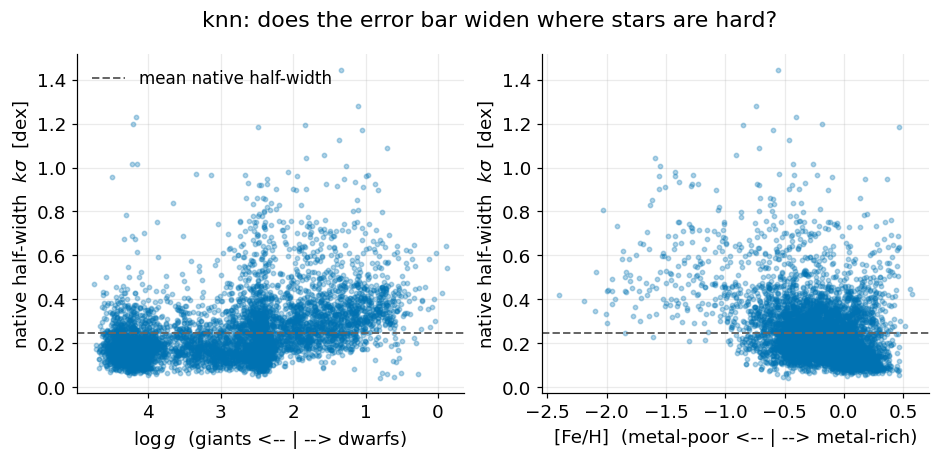

In [9]:
# Does the native half-width grow where the stars are hard (luminous giants, metal-poor)?
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
half = k * sigma
axes[0].scatter(logg_test, half, s=8, alpha=0.3, color=COLORS.get(MODEL, COLORS["accent"]))
axes[0].axhline(np.mean(half), ls="--", color="0.4", lw=1.3, label="mean native half-width")
axes[0].set_xlabel(r"$\log g$  (giants <-- | --> dwarfs)"); axes[0].set_ylabel(r"native half-width  $k\sigma$  [dex]")
axes[0].invert_xaxis(); axes[0].legend()
axes[1].scatter(feh_test, half, s=8, alpha=0.3, color=COLORS.get(MODEL, COLORS["accent"]))
axes[1].axhline(np.mean(half), ls="--", color="0.4", lw=1.3)
axes[1].set_xlabel(r"[Fe/H]  (metal-poor <-- | --> metal-rich)"); axes[1].set_ylabel(r"native half-width  $k\sigma$  [dex]")
fig.suptitle(f"{MODEL}: does the error bar widen where stars are hard?")
savefig(f"{MODEL}_native_width_vs_logg_FeH.png"); plt.show()

## 4 · Is it calibrated? Three questions

We judge an interval on three things:

1. **Marginal coverage** — one number versus the 90% target.
2. **Reliability across the data** — is it honest *everywhere* (every `log g`, every `[Fe/H]`), not
   just on average?
3. **Sharpness / width** — define **width** = `upper − lower`; narrower is better, *but only if
   coverage still holds*.

The headline idea: **marginal ≠ conditional.** A method can be 90% on average yet quietly wrong for
giants or metal-poor stars. **Marginal coverage** is the overall number; **conditional coverage** is
being right *within every* subgroup. Never report only the overall number.

And remember: **coverage without width is meaningless** — an interval from −∞ to +∞ covers 100% of
the time and tells you nothing.

In [10]:
cov_native = empirical_coverage(y_test_feh, native_lower, native_upper)   # <- your turn: read this number
print(f"{MODEL} native interval: empirical coverage = {cov_native:.1%}   (target = {TARGET_LEVEL:.0%})")
print(f"compare -- shared constant interval was {cov_shared:.1%}")
# <- look for: is your native coverage above or below 90%? It is NOT automatically calibrated either way.

knn native interval: empirical coverage = 89.0%   (target = 90%)
compare -- shared constant interval was 91.8%


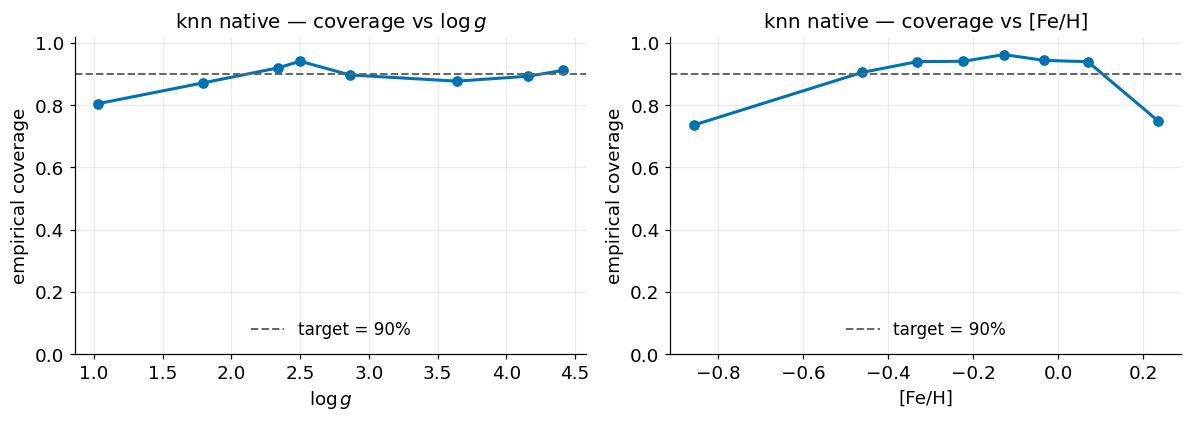

In [11]:
# Same diagnostic as §2, now on YOUR native interval — sliced by both axes.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_reliability(y_test_feh, native_lower, native_upper, target=TARGET_LEVEL,
                 feature=logg_test, feature_name=r"$\log g$", ax=axes[0])
axes[0].set_title(rf"{MODEL} native — coverage vs $\log g$")
plot_reliability(y_test_feh, native_lower, native_upper, target=TARGET_LEVEL,
                 feature=feh_test, feature_name=r"[Fe/H]", ax=axes[1])
axes[1].set_title(f"{MODEL} native — coverage vs [Fe/H]")
fig.tight_layout()
savefig(f"{MODEL}_native_reliability.png")
plt.show()
# <- look for: which bins sag below 90%? Compare to the shared-interval plots (§2). Giants? Metal-poor?

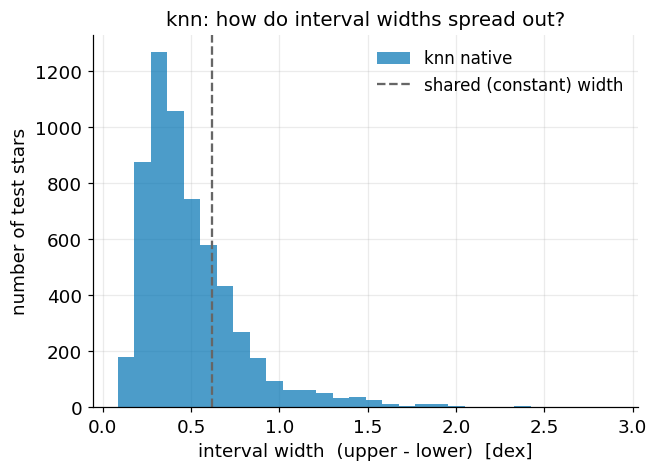

median native width = 0.421 dex   vs   constant width = 0.620 dex


In [12]:
shared_w = (shared_upper - shared_lower)      # constant -> a single spike
native_w = (native_upper - native_lower)      # varies per star
fig, ax = plt.subplots()
ax.hist(native_w, bins=30, alpha=0.7, color=COLORS.get(MODEL, COLORS["accent"]), label=f"{MODEL} native")
ax.axvline(shared_w.mean(), ls="--", color="0.4", lw=1.5, label="shared (constant) width")
ax.set_xlabel("interval width  (upper - lower)  [dex]"); ax.set_ylabel("number of test stars")
ax.set_title(f"{MODEL}: how do interval widths spread out?")
ax.legend(); savefig(f"{MODEL}_native_width_hist.png"); plt.show()
print(f"median native width = {np.median(native_w):.3f} dex   vs   constant width = {shared_w[0]:.3f} dex")
# <- look for: the shared interval is ONE spike (same for all); your native widths form a DISTRIBUTION.
#    Are the widest intervals the ones you'd WANT to be wide (giants, metal-poor)?

## 5 · Explore (open prompts)

No single right answer — bring one annotated plot to the debrief.

1. **Aleatoric or epistemic?** Plot your per-star `sigma` against `[Fe/H]` *and* across the
   **Kiel plane** (Teff vs `log g`). Does it grow smoothly with metallicity (aleatoric,
   heteroscedastic) or spike in the sparse giant / metal-poor-halo corner (epistemic)? Which flavour
   does *your* model's uncertainty mostly capture?
2. **Where is it over/under-confident?** Find the test stars where the truth fell *outside* your
   interval. Are they clustered (giants? metal-poor?) or scattered? What would you tell someone
   relying on those predictions?
3. **(Stretch) A more robust scale.** Recompute the shared σ with the **MAD**
   (`1.4826 * median(|r − median(r)|)`) instead of `std`. Does marginal coverage change? When would
   a robust scale matter?

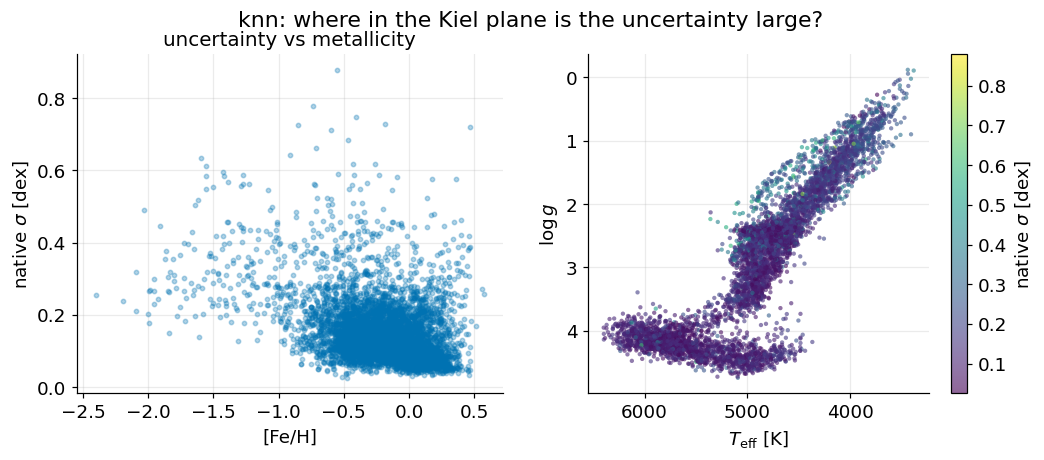

In [13]:
# A starting point for prompt 1 — extend it however you like.
Teff_test = sp["y_test"]["Teff"].to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(feh_test, sigma, s=8, alpha=0.3, color=COLORS.get(MODEL, COLORS["accent"]))
axes[0].set_xlabel(r"[Fe/H]"); axes[0].set_ylabel(r"native $\sigma$ [dex]")
axes[0].set_title("uncertainty vs metallicity")
sc = axes[1].scatter(Teff_test, logg_test, c=sigma, s=8, alpha=0.6)
axes[1].set_xlabel(r"$T_\mathrm{eff}$ [K]"); axes[1].set_ylabel(r"$\log g$")
axes[1].invert_xaxis(); axes[1].invert_yaxis()
fig.colorbar(sc, ax=axes[1], label=r"native $\sigma$ [dex]")
fig.suptitle(f"{MODEL}: where in the Kiel plane is the uncertainty large?")
plt.show()
# <- your turn: which corner has the biggest sigma? The giant branch? The metal-poor halo? Aleatoric or epistemic?

## 6 · Save your native interval for Notebook 4

Notebook 4 will **conformalize** this same model and compare against today's native interval, so we
save the native interval in the locked schema:

`outputs/{MODEL}_native_intervals.npz` with keys `y_test_true, lower, upper, target`.

We save the **§3 model-matched** interval (the one that's *yours*), not the shared baseline.

In [14]:
path = save_outputs(f"{MODEL}_native_intervals.npz",
                    y_test_true=y_test_feh,
                    lower=native_lower,
                    upper=native_upper,
                    target=TARGET_LEVEL)
print("saved ->", path)

# Sanity re-load so you SEE the contract Notebook 4 will read:
chk = load_outputs(f"{MODEL}_native_intervals.npz")
print("keys:", list(chk.keys()),
      "| coverage re-check:",
      f"{empirical_coverage(chk['y_test_true'], chk['lower'], chk['upper']):.1%}",
      "| target:", float(chk["target"]))

saved -> /mnt/c/Users/joshs/Dropbox/GitHub/utssrp-2026/outputs/knn_native_intervals.npz
keys: ['y_test_true', 'lower', 'upper', 'target'] | coverage re-check: 89.0% | target: 0.9


## Recap & the cliffhanger

**What we did:** turned point predictions into intervals two ways — a **shared constant** band and a
**model-matched** band; measured coverage, sliced it by `log g` and `[Fe/H]`, and looked at the
spread of widths.

**What we found:** marginal coverage looks ≈ 90%, but **luminous giants and metal-poor stars are
under-covered** — the constant interval can't widen where the data is genuinely harder
(aleatoric / heteroscedastic), and the model-native spreads capture only part of it (and aren't
automatically calibrated — KNN ≈ on target, RF over-covers, NN under-covers).

**The open problem for Notebook 4:** can we get a **guaranteed** coverage level *without* trusting a
Gaussian assumption? → **conformal prediction.** And does it fix the *giant / metal-poor* gap, or
only the average? *(Preview: it fixes the average; the conditional gap survives — that's the poster
headline.)*

### What got saved today

- `outputs/{MODEL}_native_intervals.npz` — keys `y_test_true, lower, upper, target` (feeds Notebook 4).
- Figures in `figures/`: `{MODEL}_shared_reliability_vs_logg.png`,
  `{MODEL}_shared_reliability_vs_FeH.png`, `{MODEL}_native_width_vs_logg_FeH.png`,
  `{MODEL}_native_reliability.png`, `{MODEL}_native_width_hist.png`.

These feed Notebook 4 and the poster.